# Neural Network Test Run (4)

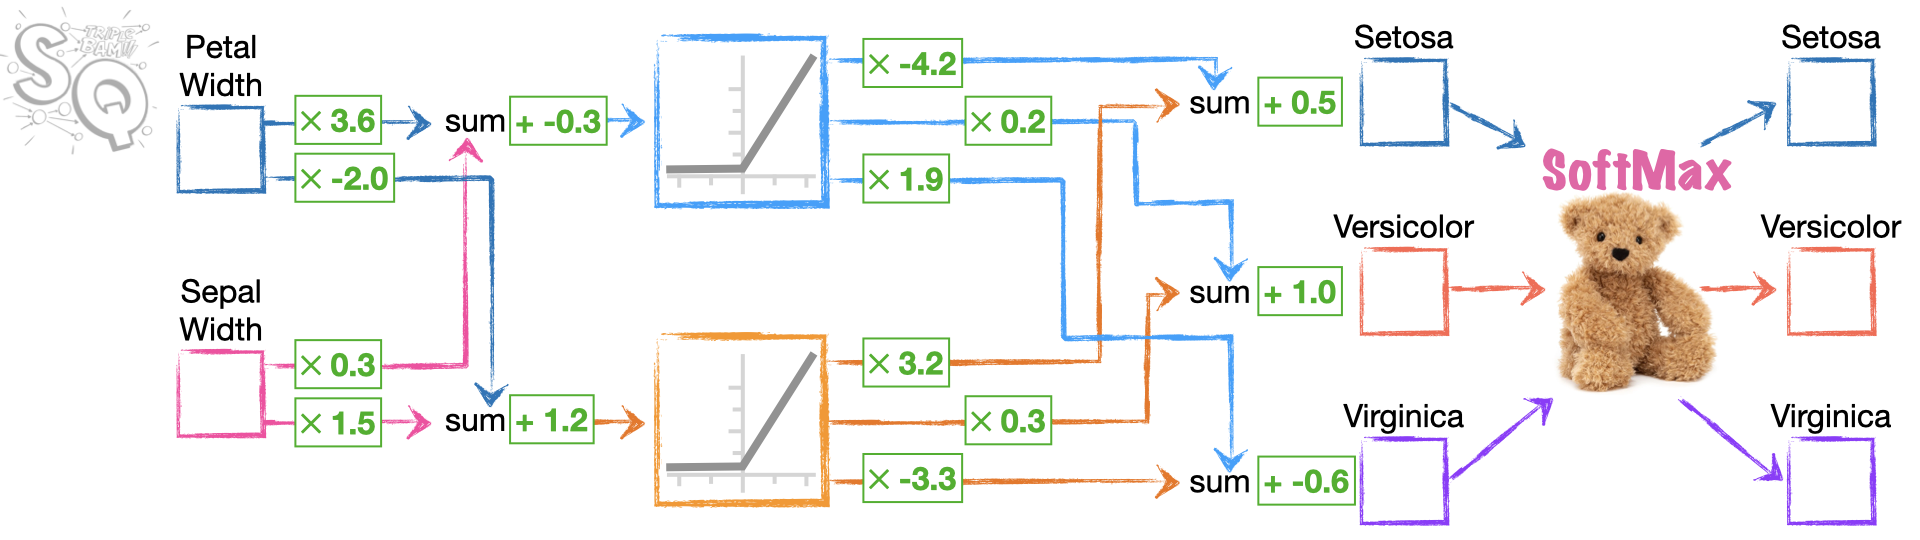

In [1]:
%%capture
# %%capture prevents this cell from printing a ton of STDERR stuff to the screen

## First, check to see if lightning is installed, if not, install it.
##
## NOTE: If you **do** need to install something, just know that you may need to
##       restart your session for python to find the new module(s).
##
##       To restart your session:
##       - In Google Colab, click on the "Runtime" menu and select
##         "Restart Session" from the pulldown menu
##       - In a local jupyter notebook, click on the "Kernel" menu and select
##         "Restart Kernel" from the pulldown menu
import pip
try:
  __import__("lightning")
except ImportError:
  pip.main(['install', "lightning"])

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torch.optim import Adam 

import lightning as L 
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
url = './iris.txt'
df = pd.read_table(url, sep=",", header=None)

In [4]:
df.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.columns = ["sepal_length", 
              "sepal_width", 
              "petal_length", 
              "petal_width", 
              "class"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.shape

(150, 5)

In [8]:
df['class'].nunique()

3

In [9]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [10]:
for class_name in df['class'].unique():
  print(class_name, ':', sum(df['class'] == class_name), sep="")

Iris-setosa:50
Iris-versicolor:50
Iris-virginica:50


In [11]:
df[['petal_width', 'sepal_width']].head()

,petal_width,sepal_width
0,0.2,3.5
1,0.2,3.0
2,0.2,3.2
3,0.2,3.1
4,0.2,3.6


In [12]:
input_values = df[['petal_width', 'sepal_width']]
input_values.head()

,petal_width,sepal_width
0,0.2,3.5
1,0.2,3.0
2,0.2,3.2
3,0.2,3.1
4,0.2,3.6


In [13]:
label_values = df['class']
label_values.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: str

In [15]:
classes_as_numbers = label_values.factorize()[0]
classes_as_numbers

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
input_train, input_test, label_train, label_test = train_test_split(input_values, 
                                                                    classes_as_numbers, 
                                                                    test_size=0.25, 
                                                                    stratify=classes_as_numbers, 
                                                                    random_state=42)

In [17]:
input_train.shape

(112, 2)

In [18]:
label_train.shape

(112,)

In [19]:
input_test.shape

(38, 2)

In [20]:
label_test.shape

(38,)

In [21]:
one_hot_label_train = F.one_hot(torch.tensor(label_train)).type(torch.float32)

In [22]:
label_train

array([2, 2, 1, 1, 1, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 2, 0, 0, 1, 1, 1,
       0, 1, 2, 0, 2, 1, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0, 1, 0, 0, 1, 2, 2,
       0, 2, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1,
       0, 2, 1, 2, 1, 2, 2, 0, 2, 1, 0, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 2,
       2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 0, 0,
       1, 0])

In [24]:
one_hot_label_train[:10]

tensor([[0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.]])

In [25]:
input_train

,petal_width,sepal_width
130,1.9,2.8
122,2.0,2.8
81,1.0,2.4
71,1.3,2.8
89,1.3,2.5
...,...,...
49,0.2,3.3
21,0.4,3.7
45,0.3,3.0
92,1.2,2.6


In [26]:
max_vals_in_input_train = input_train.max()
max_vals_in_input_train

petal_width    2.5
sepal_width    4.4
dtype: float64

In [27]:
min_vals_in_input_train = input_train.min()
min_vals_in_input_train

petal_width    0.1
sepal_width    2.0
dtype: float64

In [28]:
# Normalize with max and min.
input_train = (input_train - min_vals_in_input_train) / (max_vals_in_input_train - min_vals_in_input_train)
input_train.head()

,petal_width,sepal_width
130,0.750000,0.333333
122,0.791667,0.333333
81,0.375000,0.166667
71,0.500000,0.333333
89,0.500000,0.208333


In [29]:
# Normalize test
input_test = (input_test - min_vals_in_input_train) / (max_vals_in_input_train - min_vals_in_input_train)
input_test.head()

,petal_width,sepal_width
42,0.041667,0.500000
56,0.625000,0.541667
99,0.500000,0.333333
53,0.500000,0.125000
38,0.041667,0.416667


In [30]:
# DataLoader lets us load data in batches, and can be used to train NN.
# Convert input_train into TENSORS
input_train_tensors = torch.tensor(input_train.values).type(torch.float32)
input_train_tensors[:5]

tensor([[0.7500, 0.3333],
        [0.7917, 0.3333],
        [0.3750, 0.1667],
        [0.5000, 0.3333],
        [0.5000, 0.2083]])

In [31]:
# Convert input_test into TENSORS
input_test_tensors = torch.tensor(input_test.values).type(torch.float32)
input_test_tensors[:5]

tensor([[0.0417, 0.5000],
        [0.6250, 0.5417],
        [0.5000, 0.3333],
        [0.5000, 0.1250],
        [0.0417, 0.4167]])

In [32]:
# Combine input_train_tensors with the ONE HOT ENCODED labels. Load into DataLoader our TensorDataset.
train_dataset = TensorDataset(input_train_tensors, one_hot_label_train)
train_dataloader = DataLoader(train_dataset)

In [33]:
train_dataset

In [36]:
train_dataloader

## Build the NN

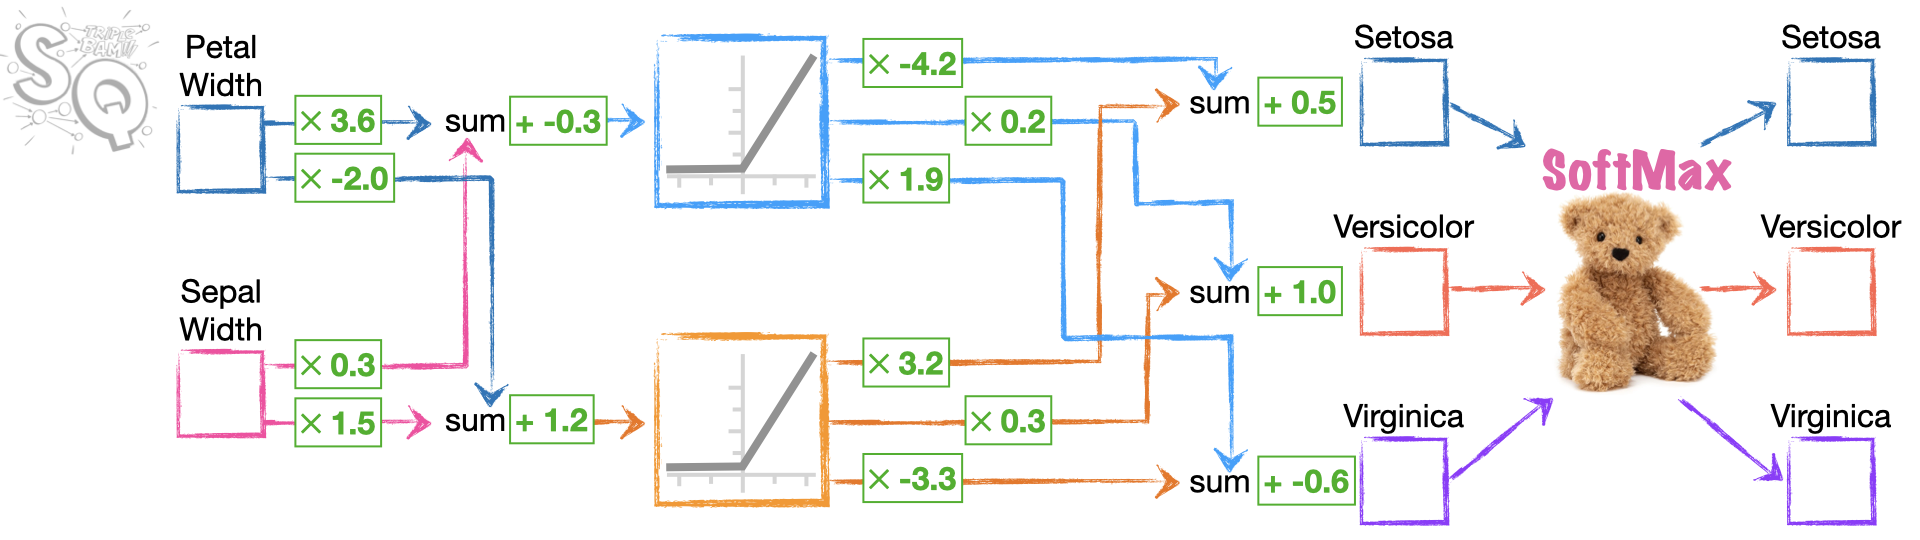

* Building a neural network with PyTorch means creating a new class. And to make it easy to train the neural network, this class will inherit from LightningModule.

* Our new class will have the following methods:

  - __init__() to initialize the Weights and Biases and keep track of a few other housekeeping things.

  - forward() to make a forward pass through the neural network.

  - configure_optimizers() to configure the optimizer. There are lots of optimizers to choose from, but in this tutorial, we'll change things up and use Adam.

  - training_step() to pass the training data to forward(), calculate the loss and keep track of the loss values in a log file.

In [37]:
class MultipleInsOuts(L.LightningModule):
  
  def __init__(self):
    super().__init__()
    
    # Random seed
    L.seed_everything(seed=42)
    
    # Initialize weights and bias.
    
    # At start of NN, we have 2 inputs that leas to 2 activation functions. 
    # Create connections and initialize weights and bias with nn.Linear() by setting in_features=2 and out_features=2
    self.input_to_hidden = nn.Linear(in_features=2, out_features=2, bias=True)
    
    # The 2 activation functions are connected to 3 outputs.
    ## We create these connections and initialize their Weights and Biases
    ## with the nn.Linear() function by setting in_features=2 and out_features=3.
    self.hidden_to_output = nn.Linear(in_features=2, out_features=3, bias=True)
    
    # We'll use Cross Entropy to calculate the loss between what the NN's predictions and actual, or known, species for each row in the dataset.
    self.loss = nn.CrossEntropyLoss()
    
  
  
  def forward(self, input):
    # Run the input values in the activation function in the hidden layer.
    hidden = self.input_to_hidden(input)
    ## Then we run the values through a ReLU activation function
    ## and then run those values to the output.
    output_values = self.hidden_to_output(torch.relu(hidden))
    return(output_values)
  
  
  def configure_optimizers(self):
    ## In this example, configuring the optimizer
    ## consists of passing it the weights and biases we want
    ## to optimize, which are all in self.parameters(),
    ## and setting the learning rate with lr=0.001.
    return Adam(self.parameters(), lr=0.001)

  
  def training_step(self, batch, batch_idx):
    ## The first thing we do is split 'batch'
    ## into the input and label values.
    inputs, labels = batch
    
    ## Then we run the input through the neural network
    outputs = self.forward(inputs)
    
     ## Then we calculate the loss.
    loss = self.loss(outputs, labels)
    return loss    

## Training NN

In [38]:
model = MultipleInsOuts()

In [39]:
# Start with 10 epochs.
trainer = L.Trainer(max_epochs=10)
trainer.fit(model, train_dataloaders=train_dataloader)

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consid

Epoch 9: 100%|██████████| 112/112 [00:01<00:00, 93.41it/s, v_num=10] 


In [40]:
predictions = model(input_test_tensors)

* Now, because our neural network has three outputs, one for Setosa, one for Versicolor, and one for Virginica, we should get 3 values for each row in input_test_tensors. We can verify that by looking at the first few rows of predictions.

In [41]:
predictions[0:4, ]

tensor([[ 0.9644, -0.1377,  0.0748],
        [ 0.0507,  0.5664,  0.8702],
        [ 0.1509,  0.4944,  0.6980],
        [ 0.1030,  0.5353,  0.6764]], grad_fn=<SliceBackward0>)

* We can determine which species was predicted in predictions by selecting the index in each row that corresponding to the largest value, and we do that with torch.argmax(). torch.argmax() returns a tensor that contains the indices with the largest values for each row.

In [42]:
## Select the output with highest value...
predicted_labels = torch.argmax(predictions, dim=1) ## dim=0 applies argmax to rows, dim=1 applies argmax to columns
predicted_labels[0:4] # print out the first 4 predictions

tensor([0, 2, 2, 2])

* In the first row index 0 had the largest value. Thus, the first prediction corresponds to Setosa. 

* The second, third, and fourth rows predicted 2, which corresponds to Virginica.

* Now, let's compare what the neural network predicted in predicted_labels to the known values in label_test and calculate the percentage of correct predictions. We do this by adding up the number of times an element in predicted_labels equals the corresponding element in label_test and dividing by the number of elements in predicted_labels.

In [44]:
## Now compare predicted_labels with test_labels to calculate accuracy
## NOTE: torch.eq() computes element-wise equality between two tensors.
##       label_test, however, is just an array, so we convert it to a tensor
##       before passing it in. torch.sum() then adds up all of the "True"
##       output values to get the number of correct predictions.
##       We then divide the number of correct predictions by the number of predicted values,
##       obtained with len(predicted_labels), to get the percentage of correct predictions
torch.sum(torch.eq(torch.tensor(label_test), predicted_labels)) / len(predicted_labels)

tensor(0.6579)

* And we see that our neural network only correctly predicts 66% of the testing data. This isn't very good. So, will training our model for more epochs improve the model's predictions?

* One way to answer that question is to just train for longer and see what happens.

* The good news is that because we're using Lightning, we can pick up where we left off training without starting over from scratch. This is because training with Lightning creates checkpoint files that keep track of the Weights and Biases as they change. As a result, all we have to do to pick up where we left off is tell the Trainer where the checkpoint files are. This is awesome and will save us a lot of time since we don't have to retrain the first 10 epochs. So, let's add an additional 90 epochs to the training.

* To add additional epochs to the training, we first identify where the checkpoint file is with the following command.

In [45]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path

* Then we create a new Lightning Trainer, just like before, but we set the number of epochs to 100. Given that we already trained for 10 epochs, this means we'll do 90 more.

In [46]:
# Create new Lightning Trainer
trainer = L.Trainer(max_epochs=100)

trainer.fit(model, train_dataloaders=train_dataloader, ckpt_path=path_to_checkpoint)

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from '/Users/svenwu/Hustle/MachineLearning/neural_networks/statquest/lightning_logs/version_10/checkpoints' to '/Users/svenwu/Hustle/MachineLearning/neural_networks/statquest/lightning_logs/version_11/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of t

Epoch 99: 100%|██████████| 112/112 [00:00<00:00, 134.45it/s, v_num=11]


In [47]:
predictions = model(input_test_tensors)
predicted_labels = torch.argmax(predictions, dim=1)

torch.sum(torch.eq(torch.tensor(label_test), predicted_labels)) / len(predicted_labels)

tensor(0.9474)

* After 100 training epochs, we correctly classified 95% of the testing data.

In [48]:
for name, param in model.named_parameters():
    print(name, torch.round(param.data, decimals=2))

input_to_hidden.weight tensor([[ 3.5500,  0.2500],
        [-1.9600,  1.4800]])
input_to_hidden.bias tensor([-0.3400,  1.2400])
hidden_to_output.weight tensor([[-4.2000,  3.1500],
        [ 0.1600,  0.3300],
        [ 1.8700, -3.2900]])
hidden_to_output.bias tensor([ 0.4600,  0.9600, -0.6100])


## Make a Prediction with New Data

* Now that our model is trained, we can use it to make predictions from new data. This is done by passing the model a tensor with normalized petal and sepal widths wrapped up in a tensor, and then passing the model output to torch.argmax().

* For example, if the raw petal and sepal width measurements were 0.2 and 3.0, we would first normalize them using the maximum and minimum values we calculated with the training data.

In [49]:
normalized_values = ([0.2, 3.0] - min_vals_in_input_train) / (max_vals_in_input_train - min_vals_in_input_train)
normalized_values

petal_width    0.041667
sepal_width    0.416667
dtype: float64

* Then we convert normalized_values into a tensor and pass it to the model, and pass the output to the argmax() function

In [51]:
# torch.argmax(model(torch.tensor(normalized_values).type(torch.float32)))
input_tensor = torch.tensor(normalized_values.values, dtype=torch.float32)

torch.argmax(model(input_tensor))

tensor(0)

* And the output is 0, meaning that the neural network predicts that the measurements come from Setosa.